# 第 2 章 自然语言和单词的分布式表示

自然语言的根本目标是让计算机理解我们的语言。

## 2.1 什么是自然语言处理

我们平常使用的语言，如日语或英语，称为自然语言（natural language）​。所谓自然语言处理（Natural Language Processing,NLP）​，顾名思义，就是处理自然语言的科学。简单地说，它是一种能够让计算机理解人类语言的技术。换言之，自然语言处理的目标就是让计算机理解人说的话，进而完成对我们有帮助的事情。

## 2.2 同义词词典

要表示单词含义，首先可以考虑通过人工方式来定义单词含义。一种方法是像《新华字典》那样，一个词一个词地说明单词含义。

但是，目前被广泛使用的并不是《新华字典》那样的常规词典，而是一种被称为同义词词典（thesaurus）的词典。在同义词词典中，具有相同含义的单词（同义词）或含义类似的单词（近义词）被归类到同一个组中。

另外，在自然语言处理中用到的同义词词典有时会定义单词之间的粒度更细的关系，比如“上位-下位”关系、​“整体-部分”关系。

像这样，通过对所有单词创建近义词集合，并用图表示各个单词的关系，可以定义单词之间的联系。利用这个“单词网络”​，可以教会计算机单词之间的相关性。也就是说，我们可以将单词含义（间接地）教给计算机，然后利用这一知识，就能让计算机做一些对我们有用的事情。

### 2.2.1 WordNet

在自然语言处理领域，最著名的同义词词典是WordNet。

使用WordNet，可以获得单词的近义词，或者利用单词网络。使用单词网络，可以计算单词之间的相似度。

### 2.2.2 同义词词典的问题

1. 难以顺应时代变换
2. 人力成本高
3. 无法单词的微妙差异

> 不仅限于自然语言处理，在图像识别领域，多年来也一直是人工设计特征量。但是，随着深度学习的出现，现在从原始图像直接获得最终结果已成为可能，人为介入的必要性大幅降低。在自然语言处理领域也有类似现象。

## 2.3 基于计数的方法

基于计数的方法需要用到语料库，语料库就是大量的文本数据。不过，语料库并不是胡乱收集数据，一般收集的都是用于自然语言处理研究和应用的文本数据。

不过，其中的文章都是由人写出来的。换句话说，语料库中包含了大量的关于自然语言的实践知识，即文章的写作方法、单词的选择方法和单词含义等。基于计数的方法的目标就是从这些富有实践知识的语料库中，自动且高效地提取本质。

### 2.3.1 基于 Python 的语料库预处理

自然语言处理领域存在各种各样的语料库。说到有名的语料库，有Wikipedia和Google News等。



In [1]:
def preprocess(text):
  """
  语料库预处理函数，将语料库转换成 id 列表、单词与id的映射、id与单词的映射。
  """
  words = text.lower().replace('.', ' .').split(' ')
  id_to_word = {}
  word_to_id = {}
  for word in words:
    if word not in word_to_id:
      new_id = len(id_to_word)
      id_to_word[new_id] = word
      word_to_id[word] = new_id



  corpus = [word_to_id[word] for word in words]
  return corpus, word_to_id, id_to_word


messages = "You say goodbye and i say hello."
corpus, word_to_id, id_to_word = preprocess(messages)
print(corpus)
print(word_to_id)
print(id_to_word)

[0, 1, 2, 3, 4, 1, 5, 6]
{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


### 2.3.2 单词的分布式表示

单词的分布式表示将单词表示为固定长度的向量。这种向量的特征在于它是用密集向量表示的。密集向量的意思是，向量的各个元素（大多数）是由非0实数表示的。例如，三维分布式表示是[0.21,-0.45,0.83]​。

### 2.3.3 分布式假设

在自然语言处理的历史中，用向量表示单词的研究有很多。如果仔细看一下这些研究，就会发现几乎所有的重要方法都基于一个简单的想法，这个想法就是“某个单词的含义由它周围的单词形成”​，称为分布式假设（distributional hypothesis）​。许多用向量表示单词的近期研究也基于该假设。

分布式假设所表达的理念非常简单。单词本身没有含义，单词含义由它所在的上下文（语境）形成。

从现在开始，我们会经常使用“上下文”一词。本章说的上下文是指某个单词（关注词）周围的单词。

这里，我们将上下文的大小（即周围的单词有多少个）称为窗口大小（window size）​。窗口大小为1，上下文包含左右各1个单词；窗口大小为2，上下文包含左右各2个单词，以此类推。

### 2.3.4 共现矩阵

下面，我们来考虑如何基于分布式假设使用向量表示单词，最直截了当的实现方法是对周围单词的数量进行计数。具体来说，在关注某个单词的情况下，对它的周围出现了多少次什么单词进行计数，然后再汇总。这里，我们将这种做法称为“基于计数的方法”​，在有的文献中也称为“基于统计的方法”​。

我们基于之前实现的语料库预处理的结果来完成语料库中每个单词的共现矩阵计算。



In [2]:
import numpy as np

def create_co_matrix(corpus, vocsize, window_size=1):
  """
  根据语料库对应的单词id列表计算共现矩阵
  """
  corpus_size = len(corpus)
  co_matrix = np.zeros((vocsize, vocsize), dtype=np.int8)
  # 遍历语料库中的每个单词，根据上下文窗口大小，计算当前单词对应的矩阵索引，更新矩阵索引对应的单词个数
  for index, word_id in enumerate(corpus):
    for i in range(1, window_size + 1):
      left_index = index - i
      right_index = index + i
      # 注意上下文左侧边界
      if left_index >= 0:
        co_matrix[word_id, corpus[left_index]] += 1
      # 注意上下文右侧边界
      if right_index < corpus_size:
        co_matrix[word_id, corpus[right_index]] += 1
  return co_matrix

messages = "You say goodbye and i say hello."
corpus, word_to_id, id_to_word = preprocess(messages)
print(corpus)
print(word_to_id)
print(id_to_word)
co_matrix = create_co_matrix(corpus, len(id_to_word))
print(co_matrix)

[0, 1, 2, 3, 4, 1, 5, 6]
{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]


### 2.3.5 向量间的相似度

测量向量间的相似度有很多方法，其中具有代表性的方法有向量内积或欧式距离等。虽然除此之外还有很多方法，但是在测量单词的向量表示的相似度方面，余弦相似度（cosine similarity）是很常用的。

余弦相似度的计算公式如下：

$$
similarity(x, y) = \frac{x ⋅ y}{|x||y|}=\frac{x_1y_1+x_2y_2+...+x_ny_n}{\sqrt{x_1^2+x_2^2+...+x_n^2}\sqrt{y_1^2+y_2^2+...+y_n^2}}
$$



#### 向量内积与欧式距离的实现

我们将实现这两个指标，并计算语料库中 "you" 和 "say" 的相似度。

In [3]:
def cos_similarity(x, y, eps=1e-8):
    '''余弦相似度'''
    nx = x / (np.sqrt(np.sum(x ** 2)) + eps)
    ny = y / (np.sqrt(np.sum(y ** 2)) + eps)
    return np.dot(nx, ny)

def inner_product(x, y):
    '''向量内积'''
    return np.dot(x, y)

def euclidean_dist(x, y):
    '''欧式距离'''
    return np.sqrt(np.sum((x - y) ** 2))

# 获取 "you" 和 "say" 的向量
c0 = co_matrix[word_to_id['you']]
c1 = co_matrix[word_to_id['say']]

print(f'"you" 的向量: {c0}')
print(f'"say" 的向量: {c1}')
print('-' * 30)
print(f'内积: {inner_product(c0, c1)}')
print(f'欧式距离: {euclidean_dist(c0, c1):.4f}')
print(f'余弦相似度: {cos_similarity(c0, c1):.4f}')

"you" 的向量: [0 1 0 0 0 0 0]
"say" 的向量: [1 0 1 0 1 1 0]
------------------------------
内积: 0
欧式距离: 2.2361
余弦相似度: 0.0000


### 2.3.6 相似单词的排序

余弦相似度已经实现好了，使用这个函数，我们可以实现另一个便利的函数：当某个单词被作为查询词时，将与这个查询词相似的单词按降序显示出来。

In [4]:
def most_similar(query, word_to_id, id_to_wrod, co_matrix, top=5):
  if query not in word_to_id:
    print(f"The word '{query}' not exist.")
    return
  print(f"\nquery [{query}]")

  voc_size = len(word_to_id)
  query_id = word_to_id[query]
  query_vector = co_matrix[query_id]
  similarity = np.zeros(voc_size)

  for id in word_to_id.values():
    similarity[id] = cos_similarity(query_vector, co_matrix[id])

  count = 0
  for i in (-1 * similarity).argsort():
    if i != query_id and count < top:
      count += 1
      print(f"{id_to_word[i]}: {similarity[i]}")

most_similar('you', word_to_id, id_to_word, co_matrix)


query [you]
goodbye: 0.7071067691154799
hello: 0.7071067691154799
i: 0.7071067691154799
and: 0.0
say: 0.0


这个结果只按降序显示了you这个查询词的前5个相似单词，各个单词旁边的值是余弦相似度。观察上面的结果可知，和you最接近的单词有3个，分别是goodbye、i（=I）和hello。因为i和you都是人称代词，所以二者相似可以理解。但是，goodbye和hello的余弦相似度也很高，这和我们的感觉存在很大的差异。一个可能的原因是，这里的语料库太小了。后面我们会用更大的语料库进行相同的实验。

## 2.4 基于计数统计的方法的改进

### 2.4.1 点互信息



#### 什么是 PMI（点互信息）

共现矩阵的一个问题是，它只记录了单词共现的**绝对次数**。这意味着像 "the" 这样出现频率极高的词，会因为在任何词周围出现的次数都很多，而表现出与许多词都有很强的相关性，这显然是不合理的。

**点互信息 (PMI)** 通过考虑单词各自出现的概率来解决这个问题。其定义如下：

$$\text{PMI}(x, y) = \log_2 \frac{P(x, y)}{P(x)P(y)}$$

- $P(x)$ 和 $P(y)$ 分别是单词 $x$ 和 $y$ 在语料库中出现的概率。
- $P(x, y)$ 是 $x$ 和 $y$ 同时出现的概率（共现概率）。

如果 $x$ 和 $y$ 的共现完全是随机的，那么 $P(x, y) = P(x)P(y)$，此时 $\text{PMI} = 0$。如果 $\text{PMI}$ 越大，说明两者的相关性越强。

#### PPMI（正点互信息）

当两个单词完全不共现时，$P(x, y) = 0$，此时 $\log_2 0 = -\infty$。为了解决这个问题，在实际应用中通常使用 **PPMI (Positive PMI)**：

$$\text{PPMI}(x, y) = \max(0, \text{PMI}(x, y))$$

这样可以将所有负值和负无穷强制设为 0。

#### 补充：关于概率估计的工程实现说明

在计算 $P(x)$ 时，严格的统计学定义应使用单词在语料库中的**实际出现次数**（如 `word_counts`）。但在实际算法实现中，通常直接使用共现矩阵的行列之和（如代码中的 `S = np.sum(C, axis=0)`）。

- **原因**：在向量空间模型中，单词的含义是由其作为“上下文”出现的频率定义的。使用共现总和作为分母在数学逻辑上是自洽的。
- **效果**：在大规模语料下，共现总次数与实际词频通常呈线性比例关系。由于 PPMI 衡量的是相对相关性，这种简化处理对最终的相似度排序几乎没有负面影响，且能显著提升计算效率。

In [5]:
def ppmi(C, verbose=False, eps=1e-8):
    '''计算 PPMI 矩阵'''
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis=0)
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            # C[i, j] 是共现次数
            # S[i] 是词 i 出现的总次数, S[j] 是词 j 出现的总次数
            pmi = np.log2(C[i, j] * N / (S[i] * S[j]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total // 10 + 1) == 0:
                    print(f'{100 * cnt / total:.1f}% 已完成')
    return M

# 计算语料库的 PPMI 矩阵
W = ppmi(co_matrix)

np.set_printoptions(precision=3)
print("共现矩阵:")
print(co_matrix)
print("-" * 50)
print("PPMI 矩阵:")
print(W)

共现矩阵:
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]
--------------------------------------------------
PPMI 矩阵:
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]


#### 补充：关于共现次数与实际出现次数的差异

如刚才讨论的，`S = np.sum(C, axis=0)` 统计的是每个单词作为上下文出现的总次数。我们可以对比一下实际的单词计数：

In [6]:
# 计算实际单词出现次数
word_counts = np.zeros(len(id_to_word), dtype=np.int32)
for word_id in corpus:
    word_counts[word_id] += 1

# 对比 "say" (ID 为 1) 的计数
say_id = word_to_id['say']
print(f"'say' 的实际出现次数 (from corpus): {word_counts[say_id]}")
print(f"'say' 的共现总次数 (from co_matrix sum): {np.sum(co_matrix, axis=0)[say_id]}")

# 打印所有单词的对比
print("\n单词\t\t实际次数\t共现总和")
for i in range(len(id_to_word)):
    print(f"{id_to_word[i]:<10}\t{word_counts[i]:<8}\t{np.sum(co_matrix, axis=0)[i]}")

'say' 的实际出现次数 (from corpus): 2
'say' 的共现总次数 (from co_matrix sum): 4

单词		实际次数	共现总和
you       	1       	1
say       	2       	4
goodbye   	1       	2
and       	1       	2
i         	1       	2
hello     	1       	2
.         	1       	1


### 2.4.2 维度

所谓降维（dimensionality reduction）​，顾名思义，就是减少向量维度。但是，并不是简单地减少，而是在尽量保留“重要信息”的基础上减少。

向量中的大多数元素为0的矩阵（或向量）称为稀疏矩阵（或稀疏向量）​。这里的重点是，从稀疏向量中找出重要的轴，用更少的维度对其进行重新表示。结果，稀疏矩阵就会被转化为大多数元素均不为0的密集矩阵。这个密集矩阵就是我们想要的单词的分布式表示。

降维的方法有很多，我们下面以 SVD（奇异值分解）为例讲解降维实现。SVD将任意矩阵分解为3个矩阵的乘积：

$$
X=USV^{T}
$$

其中U和V是列向量彼此正交的正交矩阵，S是除了对角线元素以外其余元素均为0的对角矩阵。

U是正交矩阵。这个正交矩阵构成了一些空间中的基轴（基向量）​，我们可以将矩阵U作为“单词空间”​。S是对角矩阵，奇异值在对角线上降序排列。简单地说，我们可以将奇异值视为“对应的基轴”的重要性。这样一来，减少非重要元素就成为可能。

矩阵S的奇异值小，对应的基轴的重要性低，因此，可以通过去除矩阵U中的多余的列向量来近似原始矩阵。用我们正在处理的“单词的PPMI矩阵”来说明的话，矩阵X的各行包含对应的单词ID的单词向量，这些单词向量使用降维后的矩阵U′表示。

### 2.4.2 基于 SVD 的降维

我们接下来借助 NumPy 库中的 linalg 模块中的 svd 方法进行SVD计算。




In [8]:
U, S, V = np.linalg.svd(W)

print(U)
print(S)
print(V)

[[ 3.409e-01 -1.110e-16 -1.205e-01 -4.163e-16 -9.323e-01 -1.110e-16
  -2.426e-17]
 [ 0.000e+00 -5.976e-01  0.000e+00  1.802e-01  0.000e+00 -7.812e-01
   0.000e+00]
 [ 4.363e-01 -5.551e-17 -5.088e-01 -2.220e-16  2.253e-01 -1.388e-17
  -7.071e-01]
 [ 1.665e-16 -4.978e-01  2.776e-17  6.804e-01 -1.110e-16  5.378e-01
   7.467e-17]
 [ 4.363e-01 -3.124e-17 -5.088e-01 -1.600e-16  2.253e-01 -1.302e-17
   7.071e-01]
 [ 7.092e-01 -3.124e-17  6.839e-01 -1.600e-16  1.710e-01 -1.302e-17
   2.314e-17]
 [-1.665e-16 -6.285e-01 -4.163e-17 -7.103e-01  2.220e-16  3.169e-01
  -9.614e-17]]
[3.168e+00 3.168e+00 2.703e+00 2.703e+00 1.514e+00 1.514e+00 4.132e-17]
[[-0.000e+00  5.976e-01  1.665e-16  4.978e-01  2.776e-16 -2.220e-16
   6.285e-01]
 [-3.409e-01  0.000e+00 -4.363e-01  0.000e+00 -4.363e-01 -7.092e-01
  -0.000e+00]
 [ 0.000e+00 -1.802e-01  1.388e-17 -6.804e-01 -1.110e-16  8.327e-17
   7.103e-01]
 [ 1.205e-01 -5.551e-16  5.088e-01  0.000e+00  5.088e-01 -6.839e-01
  -0.000e+00]
 [-0.000e+00 -7.812e-01 -

经过上述 SVD 计算之后，变量U包含经过SVD转化的密集向量表示。现在，我们以单词ID为0的单词向量来看一下它的内容：

In [9]:
# 共现矩阵的向量
print(co_matrix[0])

# PPMI矩阵的向量
print(W[0])

# SVD 计算的向量
print(U[0])

[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[ 3.409e-01 -1.110e-16 -1.205e-01 -4.163e-16 -9.323e-01 -1.110e-16
 -2.426e-17]


如上所述，原先的稀疏向量W[0]经过SVD转换后变成了密集向量U[0]。如果要对这个密集向量降维，比如把它降维到二维向量，取前两个元素即可。

In [10]:
print(U[0, :2])

[ 3.409e-01 -1.110e-16]


这样我们就完成了降维。现在，我们用二维向量表示各个单词，并把它们画在图上，代码如下。

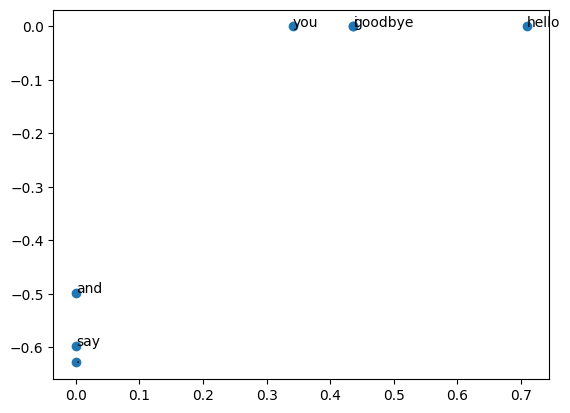

In [14]:
import matplotlib.pyplot as plt

for word, word_id in word_to_id.items():
  plt.annotate(word, (U[word_id, 0], U[word_id, 1]))
plt.scatter(U[:, 0], U[:, 1])
plt.show()

观察该图可以发现，goodbye和hello、you和i位置接近，这是比较符合我们的直觉的。但是，因为我们使用的语料库很小，有些结果就比较微妙。下面，我们将使用更大的PTB数据集进行相同的实验

### 2.4.4 PTB 数据集

### 2.4.5 基于PTB数据集的评价

## 2.5 小结



